In [1]:
import torch
import clip
from PIL import Image
from typing import Union


device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


def encode_images(images: list[Union[Image.Image, str]]) -> torch.Tensor:
    """
    Кодирует список изображений в CLIP-эмбеддинги.
    
    Args:
        images (list): список объектов PIL.Image.Image или путей к изображениям.
        
    Returns:
        torch.Tensor: матрица эмбеддингов [len(images), d]
    """
    processed = []
    for img in images:
        if isinstance(img, str):  # если путь к файлу
            img = Image.open(img).convert("RGB")
        processed.append(preprocess(img))

    image_input = torch.stack(processed).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_input)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    return image_features


def encode_text(texts: list[str]) -> torch.Tensor:
    """
    Кодирует список текстов в CLIP-эмбеддинги.
    
    Args:
        texts (list): список строк
        
    Returns:
        torch.Tensor: матрица эмбеддингов [len(texts), d]
    """
    
    text_tokens = clip.tokenize(texts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    return text_features


def reconstruction_score(generated_images: list[Union[Image.Image, str]], train_images: list[Union[Image.Image, str]]) -> float:
    """
    Считает Reconstruction Score:
    среднее попарное CLIP-сходство между сгенерированными и обучающими изображениями.
    
    Args:
        generated_images (list): список сгенерированных PIL.Image.Image или путей к файлам
        train_images (list): список реальных PIL.Image.Image или путей к файлам
        
    Returns:
        score (float): Reconstruction Score
    """
    
    gen_embeds = encode_images(generated_images)
    real_embeds = encode_images(train_images)

    sims = gen_embeds @ real_embeds.T 
    score = sims.mean().item()
    return score


def editability_score(generated_images: list[Union[Image.Image, str]], prompt_text: str) -> float:
    """
    Считает Editability Score:
    косинусное сходство между средним эмбеддингом изображений и эмбеддингом текста.
    
    Args:
        generated_images (list): список сгенерированных PIL.Image.Image или путей к файлам
        prompt_text (str): текстовый промпт БЕЗ placeholder
        
    Returns:
        score (float): Editability Score
    """
    
    gen_embeds = encode_images(generated_images)
    avg_img_embed = gen_embeds.mean(dim=0, keepdim=True)
    avg_img_embed /= avg_img_embed.norm(dim=-1, keepdim=True)

    text_embed = encode_text([prompt_text])

    score = (avg_img_embed @ text_embed.T).item()
    return score

/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
live_set = [
    'a chocolate-colored a red sks dog',
    'a purple sks dog',
    'a brightly lit sks dog',
    'a snowy sks dog',
    'sks dog',
    'a sks dog in a purple wizard outfit',
    'a sks dog in a doctor outfit',
    'a sks dog in a superhero suit',
    'a sks dog dressed as a ballerina',
    'a sks dog wearing a green bow tie',
    'a sks dog with the Eiffel Tower in the background',
    'a sks dog with a mountain in the background',
    'a sks dog with a tree and autumn leaves in the background',
    'a sks dog on top of green grass with sunflowers around it',
    'a sks dog with a sunset and palm trees in the background',
    'a sks dog with the Sydney Opera House in the background',
    'a sks dog lying in the bed',
    'a sks dog sitting on the chair',
    'a sks dog swimming',
    'a sks dog sleeping',
    'a sks dog skateboarding',
    'a sks dog riding a surfboard',
    'a sks dog jumping with a parachute',
    'a sks dog running on a treadmill',
    'a sks dog riding a bike',
    'a sks dog in a chief outfit in a nostalgic kitchen filled with vintage furniture and scattered biscuit',
    'a sks dog dressed in a superhero cape, soaring through the skies above a bustling city during a sunset',
    'a sks dog wearing a tuxedo performing on a stage in the spotlight',
    "a sks dog in a wizard’s robe in a magical forest at midnight, accented with purples and sparkling silver tones",
    'a sks dog wearing a space helmet, amongst stars in a cosmic landscape during a starry night',
    'a sks dog wearing a pirate hat exploring a sandy beach at the sunset with a boat floating in the background',
]

object_set = [
    'a chocolate-colored a sks dog made of gold',
    'a brightly lit sks dog',
    'a red sks dog',
    'a purple sks dog',
    'sks dog',
    'a sks dog on top of a red and white checkered picnic blanket',
    'a sks dog with the Eiffel Tower in the background',
    'a sks dog with a mountain in the background',
    'a sks dog with a tree and autumn leaves in the background',
    'a sks dog on top of green grass with sunflowers around it',
    'a sks dog with a sunset and palm trees in the background',
    'a sks dog with the Sydney Opera House in the background',
    'a sks dog in the snow',
    'a sks dog on the beach',
    'a sks dog on a cobblestone street',
    'a sks dog on top of a wooden floor',
    'a sks dog with a city in the background',
    'a sks dog with a blue house in the background',
    'a sks dog on top of a purple rug in a forest',
    'a sks dog with a wheat field in the background',
    'a sks dog in the bed',
    'a sks dog on the chair',
    'a sks dog on top of a snowy mountain peak',
    'a sks dog with a sand castle in the background',
    'a sks dog in a cave',
    'a sks dog on a windowsill in Tokyo at dusk, illuminated by neon city lights, using neon color palette',
    'a sks dog on a sofa in a cozy living room, rendered in warm tones',
    'a sks dog on a wooden table in a sunny backyard, surrounded by flowers and butterflies',
    'a sks dog floating in a bathtub filled with bubbles and illuminated by the warm glow of evening sunlight filtering through a nearby window',
    'a sks dog floating among stars in a cosmic landscape during a starry night with a spacecraft in the background',
    'a sks dog on a sandy beach next to the sand castle at the sunset with a floating boat in the background',
]

base_prompt = "A photo of sks dog"

In [3]:
СONFIG_PATH="/home/arteplov/T-LoRA/tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/logs/hparams.yml"

In [4]:
from tlora.inferencer_sdxl import TLoraInferencerSDXL
import yaml
from types import SimpleNamespace
import torch

In [5]:
СONFIG_PATH="/home/arteplov/T-LoRA/tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/logs/hparams.yml"
with open(СONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [6]:
args = SimpleNamespace(
    checkpoint_idx=800,
    guidance_scale=7.5,
    num_inference_steps=30,
    num_images_per_prompt=15,
    batch_size=1,
    prompts=None,
    replace_inference_output=True,
    version=0,
    seed=0,
)

prompts = [
    "A photo of sks dog"
]

inferencer = TLoraInferencerSDXL(config=config, args=args, prompts=prompts, dtype=torch.float16, device="cuda")
inferencer.setup()

/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [7]:
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

for step in steps:
    print("Используется чекпоинт:", step)

    inferencer.checkpoint_idx = step
    inferencer.checkpoint_path = f"{config['output_dir']}/checkpoint-{step}"

    inferencer.setup_model()
    inferencer.lora_layers.to("cuda")
    inferencer.setup_paths()

    inferencer.generate()         

Используется чекпоинт: 100


  0%|          | 0/1 [00:00<?, ?it/s]/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/diffusers/configuration_utils.py:139: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'EulerDiscreteScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'EulerDiscreteScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
100%|██████████| 1/1 [09:14<00:00, 554.11s/it]


Используется чекпоинт: 200


100%|██████████| 1/1 [08:56<00:00, 536.70s/it]


Используется чекпоинт: 300


...

100%|██████████| 1/1 [08:56<00:00, 536.15s/it]


Используется чекпоинт: 900


100%|██████████| 1/1 [08:55<00:00, 535.42s/it]


Используется чекпоинт: 1000


100%|██████████| 1/1 [08:56<00:00, 536.21s/it]


In [8]:
import os

In [9]:
os.listdir(f"tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-{step}/samples/ns30_gs7.5/version_0/{base_prompt}/")

['8.png',
 '6.png',
 '11.png',
 '9.png',
 '3.png',
 '.ipynb_checkpoints',
 '7.png',
 '1.png',
 '14.png',
 '4.png',
 '5.png',
 '12.png',
 '10.png',
 '0.png',
 '2.png',
 '13.png']

In [10]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4"
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
# base_prompt = "a {0} riding a bike"

images = []
titles = []

for step in steps:
    folder = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/{base_prompt}/"
    
    if os.path.exists(folder) and os.listdir(folder):
        files = [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        if files:
            img_path = os.path.join(folder, random.choice(files))
            img = Image.open(img_path)
            images.append(img)
            titles.append(f"step {step}")
        else:
            images.append(None)
            titles.append(f"step {step}\n(no images)")
    else:
        images.append(None)
        titles.append(f"step {step}\n(folder missing)")


In [11]:
images, titles

([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>],
 ['step 100',
  'step 200',
  'step 300',
  'step 400',
  'step 500',
  'step 600',
  'step 700',
  'step 800',
  'step 900',
  'step 1000'])

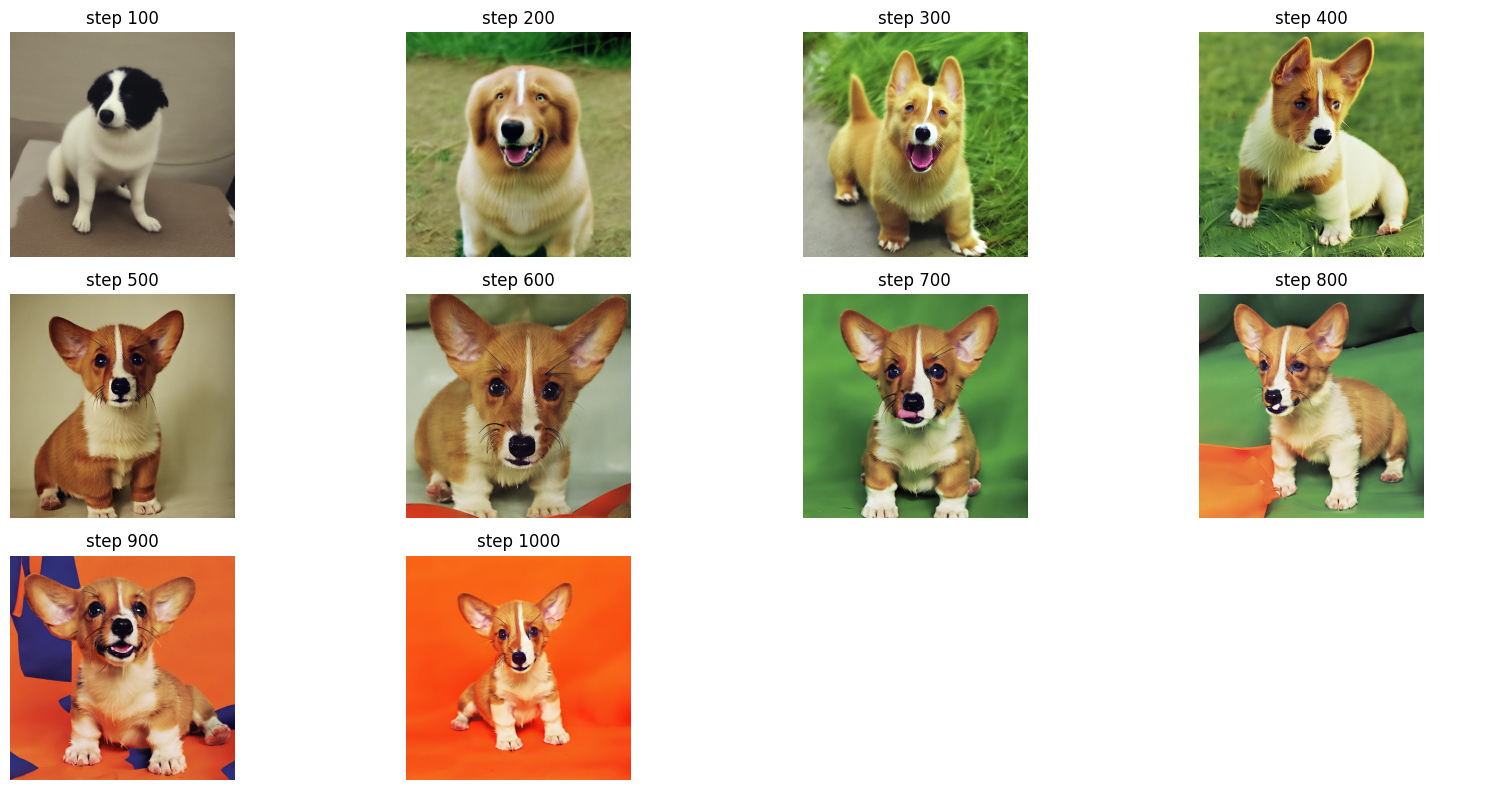

In [12]:
cols = 4 
rows = (len(images) + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(16, 8))
axs = axs.flatten()

for i, (img, title) in enumerate(zip(images, titles)):
    axs[i].set_title(title)
    axs[i].axis("off")
    if img:
        axs[i].imshow(img)

for j in range(len(images), len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# rec_scores = {}
# for step in tqdm(steps):
#     gen_base_files = glob(f"checkpoint-{step}/sample/base_*.png", recursive=True)
#     real_files = glob("../dataset/few_shot/instance_images/*", recursive=True)
    
#     score = reconstruction_score(gen_base_files, real_files)
#     rec_scores[step] = score
    
# rec_scores

In [13]:
images

[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024>]

In [19]:
def load_images(image_paths):
    imgs = []
    for p in image_paths:
        if isinstance(p, Image.Image):
            imgs.append(p)
        else:
            imgs.append(Image.open(p).convert("RGB"))
    return imgs

def compute_reconstruction_scores(steps, base_dir, base_prompt, train_dir):
    train_paths = [os.path.join(train_dir, f) for f in sorted(os.listdir(train_dir)) if f != ".ipynb_checkpoints"]
    # print(train_paths)
    train_images = load_images(train_paths)

    scores = {}

    for step in steps:
        folder = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/{base_prompt}/"

        if not os.path.exists(folder) or not os.listdir(folder):
            print(f"Step {step}: изображения не найдены")
            scores[step] = None
            continue

        gen_paths = [
            os.path.join(folder, f)
            for f in sorted(os.listdir(folder))
            if f.lower().endswith(("png", "jpg", "jpeg"))
        ]
        # print(gen_paths)
        gen_paths = gen_paths[:15]
        print(len(gen_paths))
        generated_images = load_images(gen_paths)

        score = reconstruction_score(generated_images, train_images)
        scores[step] = score
        print(f"Step {step} | score: {score:.4f}")

    return scores

In [20]:
train_path = ['/home/arteplov/T-LoRA/dog_example/00.jpg', '/home/arteplov/T-LoRA/dog_example/01.jpg', '/home/arteplov/T-LoRA/dog_example/02.jpg', '/home/arteplov/T-LoRA/dog_example/03.jpg', '/home/arteplov/T-LoRA/dog_example/04.jpg']
gen_path_test = ['tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-100/samples/ns30_gs7.5/version_0/A photo of sks dog/0.png', 'tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-100/samples/ns30_gs7.5/version_0/A photo of sks dog/1.png', 'tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-100/samples/ns30_gs7.5/version_0/A photo of sks dog/2.png', 'tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-100/samples/ns30_gs7.5/version_0/A photo of sks dog/3.png', 'tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/checkpoint-100/samples/ns30_gs7.5/version_0/A photo of sks dog/4.png']
train_images = load_images(train_path)
generated_images = load_images(gen_path_test)
score = reconstruction_score(generated_images, train_images)
score

0.802734375

In [21]:
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4"
# base_prompt = "a {0} riding a bike"
train_dir = "/home/arteplov/T-LoRA/dog_example"

scores = compute_reconstruction_scores(steps, base_dir, base_prompt, train_dir)

15
Step 100 | score: 0.7812
15
Step 200 | score: 0.7939
15
Step 300 | score: 0.8433
15
Step 400 | score: 0.8813
15
Step 500 | score: 0.9072
15
Step 600 | score: 0.9253
15
Step 700 | score: 0.9160
15
Step 800 | score: 0.9312
15
Step 900 | score: 0.9219
15
Step 1000 | score: 0.9272


In [22]:
# right_dynamic_lora_scores = {100: 0.83349609375,
#  200: 0.89013671875,
#  300: 0.90576171875,
#  400: 0.90576171875,
#  500: 0.9287109375,
#  600: 0.923828125,
#  700: 0.93798828125,
#  800: 0.935546875,
#  900: 0.94140625,
#  1000: 0.94189453125}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

In [26]:
scores

{100: 0.78125,
 200: 0.7939453125,
 300: 0.84326171875,
 400: 0.88134765625,
 500: 0.9072265625,
 600: 0.92529296875,
 700: 0.916015625,
 800: 0.93115234375,
 900: 0.921875,
 1000: 0.92724609375}

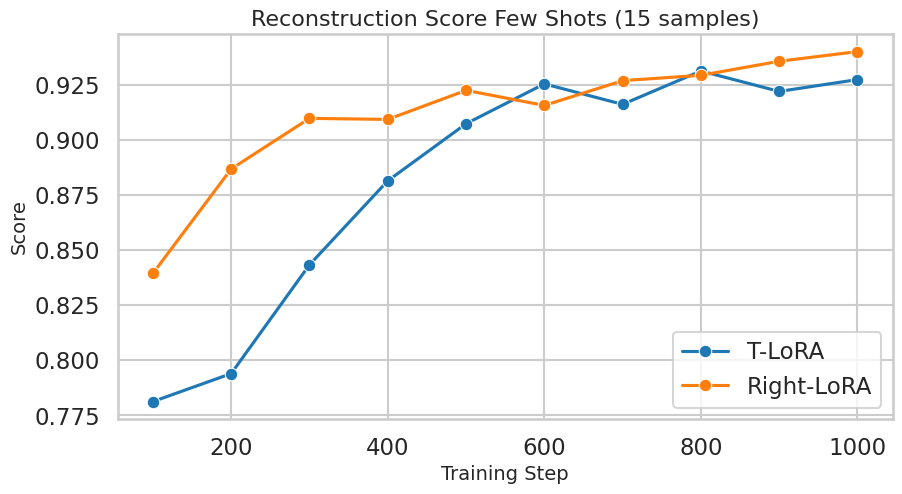

In [25]:
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
sns.set_context("talk")

df_tlora = pd.DataFrame({
    "step": list(scores.keys()),
    "score": list(scores.values())
})
df_tlora = df_tlora.dropna()

df_right_dynamic_lora = pd.DataFrame({
    "step": list(right_rec_few.keys()),
    "score": list(right_rec_few.values())
})
df_right_dynamic_lora = df_right_dynamic_lora.dropna()


plt.figure(figsize=(10, 5))
sns.lineplot(data=df_tlora, x="step", y="score", marker="o", label="T-LoRA")
sns.lineplot(data=df_right_dynamic_lora, x="step", y="score", marker="o", label="Right-LoRA")
plt.title("Reconstruction Score Few Shots (15 samples)", fontsize=16)
plt.xlabel("Training Step", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.grid(True)
# plt.tight_layout()
plt.show()

## Clean Rec Score

In [18]:
import torch
import clip
from PIL import Image
from typing import Union


device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


def encode_images(images: list[Union[Image.Image, str]]) -> torch.Tensor:
    """
    Кодирует список изображений в CLIP-эмбеддинги.
    
    Args:
        images (list): список объектов PIL.Image.Image или путей к изображениям.
        
    Returns:
        torch.Tensor: матрица эмбеддингов [len(images), d]
    """
    processed = []
    for img in images:
        if isinstance(img, str):  # если путь к файлу
            img = Image.open(img)#.convert("RGB")
        processed.append(preprocess(img))

    image_input = torch.stack(processed).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_input)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    return image_features


def encode_text(texts: list[str]) -> torch.Tensor:
    """
    Кодирует список текстов в CLIP-эмбеддинги.
    
    Args:
        texts (list): список строк
        
    Returns:
        torch.Tensor: матрица эмбеддингов [len(texts), d]
    """
    
    text_tokens = clip.tokenize(texts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    return text_features


def reconstruction_score(generated_images: list[Union[Image.Image, str]], train_images: list[Union[Image.Image, str]]) -> float:
    """
    Считает Reconstruction Score:
    среднее попарное CLIP-сходство между сгенерированными и обучающими изображениями.
    
    Args:
        generated_images (list): список сгенерированных PIL.Image.Image или путей к файлам
        train_images (list): список реальных PIL.Image.Image или путей к файлам
        
    Returns:
        score (float): Reconstruction Score
    """
    
    gen_embeds = encode_images(generated_images)
    real_embeds = encode_images(train_images)

    sims = gen_embeds @ real_embeds.T 
    score = sims.mean().item()
    return score

In [3]:
from transformers import pipeline
from glob import glob
import os
from tqdm import tqdm

In [4]:
pipe = pipeline(
    "image-segmentation", 
    model="briaai/RMBG-1.4", 
    trust_remote_code=True,
    device='cuda'
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda


In [5]:
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

In [7]:
# исходных
real_files = glob("dog_example/*", recursive=True)
os.makedirs("dog_example/few_shots/instance_images_clean", exist_ok=True)
for path in tqdm(real_files):
    name = path.split("/")[-1].strip(".jpg")
    image = pipe(path)
    image.save(f"dog_example/few_shots/instance_images_clean/{name}.png")

100%|██████████| 5/5 [00:09<00:00,  1.86s/it]


In [10]:
count = 0
# print(f"Processing: {exp}")
base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/"
for step in tqdm(steps):
    os.makedirs(f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/A photo of sks dog/clean_sample", exist_ok=True)
    path = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/A photo of sks dog/*.png"
    image_path_all = glob(path)

    for path in image_path_all:
        image = pipe(path)

        name = path.split("/")[-1]
        image.save(f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/A photo of sks dog/clean_sample/{name}")

100%|██████████| 10/10 [02:28<00:00, 14.90s/it]


In [21]:
def load_images(image_paths):
    imgs = []
    for p in image_paths:
        if isinstance(p, Image.Image):
            imgs.append(p)
        else:
            imgs.append(Image.open(p))
    return imgs

def compute_reconstruction_scores_clean(steps, base_dir, base_prompt, train_dir):
    train_paths = [os.path.join(train_dir, f) for f in sorted(os.listdir(train_dir)) if f != ".ipynb_checkpoints"]
    # print(train_paths)
    train_images = load_images(train_paths)

    scores = {}

    for step in steps:
        folder = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/{base_prompt}/clean_sample"

        if not os.path.exists(folder) or not os.listdir(folder):
            print(f"Step {step}: изображения не найдены")
            scores[step] = None
            continue

        gen_paths = [
            os.path.join(folder, f)
            for f in sorted(os.listdir(folder))
            if f.lower().endswith(("png", "jpg", "jpeg"))
        ]
        # print(gen_paths)
        gen_paths = gen_paths[:15]
        print(len(gen_paths))
        generated_images = load_images(gen_paths)

        score = reconstruction_score(generated_images, train_images)
        scores[step] = score
        print(f"Step {step} | score: {score:.4f}")

    return scores

In [22]:
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4"
# base_prompt = "a {0} riding a bike"
train_dir = "/home/arteplov/T-LoRA/dog_example/few_shots/instance_images_clean"

scores = compute_reconstruction_scores_clean(steps, base_dir, base_prompt, train_dir)

15
Step 100 | score: 0.8618
15
Step 200 | score: 0.8877
15
Step 300 | score: 0.9165
15
Step 400 | score: 0.9404
15
Step 500 | score: 0.9429
15
Step 600 | score: 0.9512
15
Step 700 | score: 0.9385
15
Step 800 | score: 0.9546
15
Step 900 | score: 0.9438
15
Step 1000 | score: 0.9507


In [23]:
scores

{100: 0.86181640625,
 200: 0.8876953125,
 300: 0.91650390625,
 400: 0.9404296875,
 500: 0.94287109375,
 600: 0.951171875,
 700: 0.9384765625,
 800: 0.95458984375,
 900: 0.94384765625,
 1000: 0.95068359375}

In [24]:
right_rec_few_clean = {100: 0.91552734375,
 200: 0.9462890625,
 300: 0.94580078125,
 400: 0.95361328125,
 500: 0.94189453125,
 600: 0.9482421875,
 700: 0.947265625,
 800: 0.94970703125,
 900: 0.9560546875,
 1000: 0.95751953125}

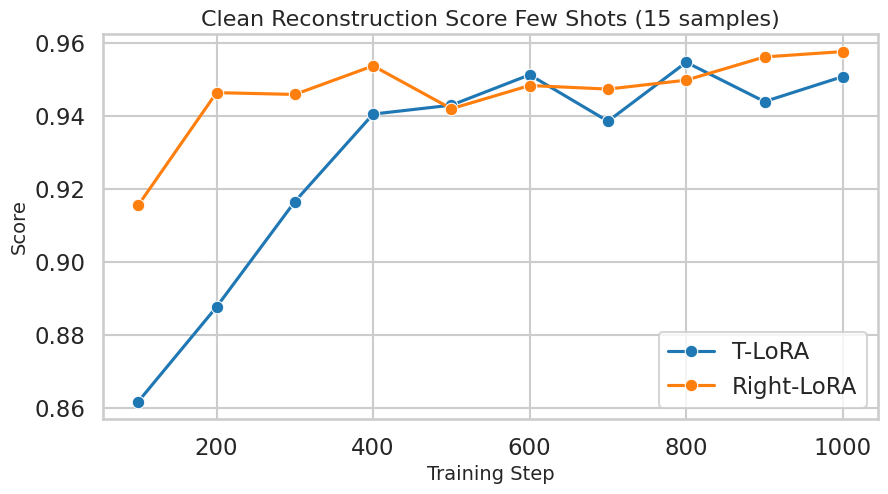

In [26]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

df_tlora = pd.DataFrame({
    "step": list(scores.keys()),
    "score": list(scores.values())
})
df_tlora = df_tlora.dropna()

df_right_dynamic_lora = pd.DataFrame({
    "step": list(right_rec_few_clean.keys()),
    "score": list(right_rec_few_clean.values())
})
df_right_dynamic_lora = df_right_dynamic_lora.dropna()


plt.figure(figsize=(10, 5))
sns.lineplot(data=df_tlora, x="step", y="score", marker="o", label="T-LoRA")
sns.lineplot(data=df_right_dynamic_lora, x="step", y="score", marker="o", label="Right-LoRA")
plt.title("Clean Reconstruction Score Few Shots (15 samples)", fontsize=16)
plt.xlabel("Training Step", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.grid(True)
# plt.tight_layout()
plt.show()

## Edit Score

In [3]:
СONFIG_PATH="/workspace/T-LoRA/trained-tlora_dog_2/00003-5298-dog_example_tortho_lora4/logs/hparams.yml"

In [4]:
from tlora.inferencer_sdxl import TLoraInferencerSDXL
import yaml
from types import SimpleNamespace
import torch

In [5]:
СONFIG_PATH="/home/arteplov/T-LoRA/tlora_1000_steps/00001-aae1-dog_example_tortho_lora4/logs/hparams.yml"
with open(СONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [6]:
args = SimpleNamespace(
    checkpoint_idx=800,
    guidance_scale=7.5,
    num_inference_steps=30,
    num_images_per_prompt=5,
    batch_size=3,
    prompts=None,
    replace_inference_output=True,
    version=0,
    seed=0,
)

prompts = [
    "A photo of sks dog"
]

inferencer = TLoraInferencerSDXL(config=config, args=args, prompts=prompts, dtype=torch.float16, device="cuda")
inferencer.setup()

/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [7]:
from tqdm import tqdm

In [8]:
# steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

steps = [600, 700, 800, 900, 1000]

for step in steps:
    print("Используется чекпоинт:", step)

    inferencer.checkpoint_idx = step
    inferencer.checkpoint_path = f"{config['output_dir']}/checkpoint-{step}"

    inferencer.setup_model()
    inferencer.lora_layers.to("cuda")
    inferencer.setup_paths()
    
#     for prompt_data in tqdm(prompts):
#         prompt = prompt_data['prompt']
#         set_type = prompt_data['set']
#         idx = prompt_data['idx']
        
#         inferencer.prompts = prompt
#         print(inferencer.prompts)

    inferencer.prompts = live_set

    inferencer.generate()         

Используется чекпоинт: 600


  0%|          | 0/31 [00:00<?, ?it/s]/home/arteplov/.conda/envs/tlora/lib/python3.11/site-packages/diffusers/configuration_utils.py:139: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'EulerDiscreteScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'EulerDiscreteScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
100%|██████████| 31/31 [1:51:22<00:00, 215.58s/it]


Используется чекпоинт: 700


100%|██████████| 31/31 [1:51:28<00:00, 215.77s/it]


Используется чекпоинт: 800


100%|██████████| 31/31 [1:51:24<00:00, 215.64s/it]


Используется чекпоинт: 900


100%|██████████| 31/31 [1:51:20<00:00, 215.51s/it]


Используется чекпоинт: 1000


100%|██████████| 31/31 [1:51:25<00:00, 215.66s/it]


In [13]:
inferencer.prompts

['A photo of sks dog']

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4"
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
prompt = 'a sks dog lying in the bed'

images = []
titles = []

for step in steps:
    folder = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/{prompt}/"
    
    if os.path.exists(folder) and os.listdir(folder):
        files = [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        if files:
            img_path = os.path.join(folder, random.choice(files))
            img = Image.open(img_path)
            images.append(img)
            titles.append(f"step {step}")
        else:
            images.append(None)
            titles.append(f"step {step}\n(no images)")
    else:
        images.append(None)
        titles.append(f"step {step}\n(folder missing)")


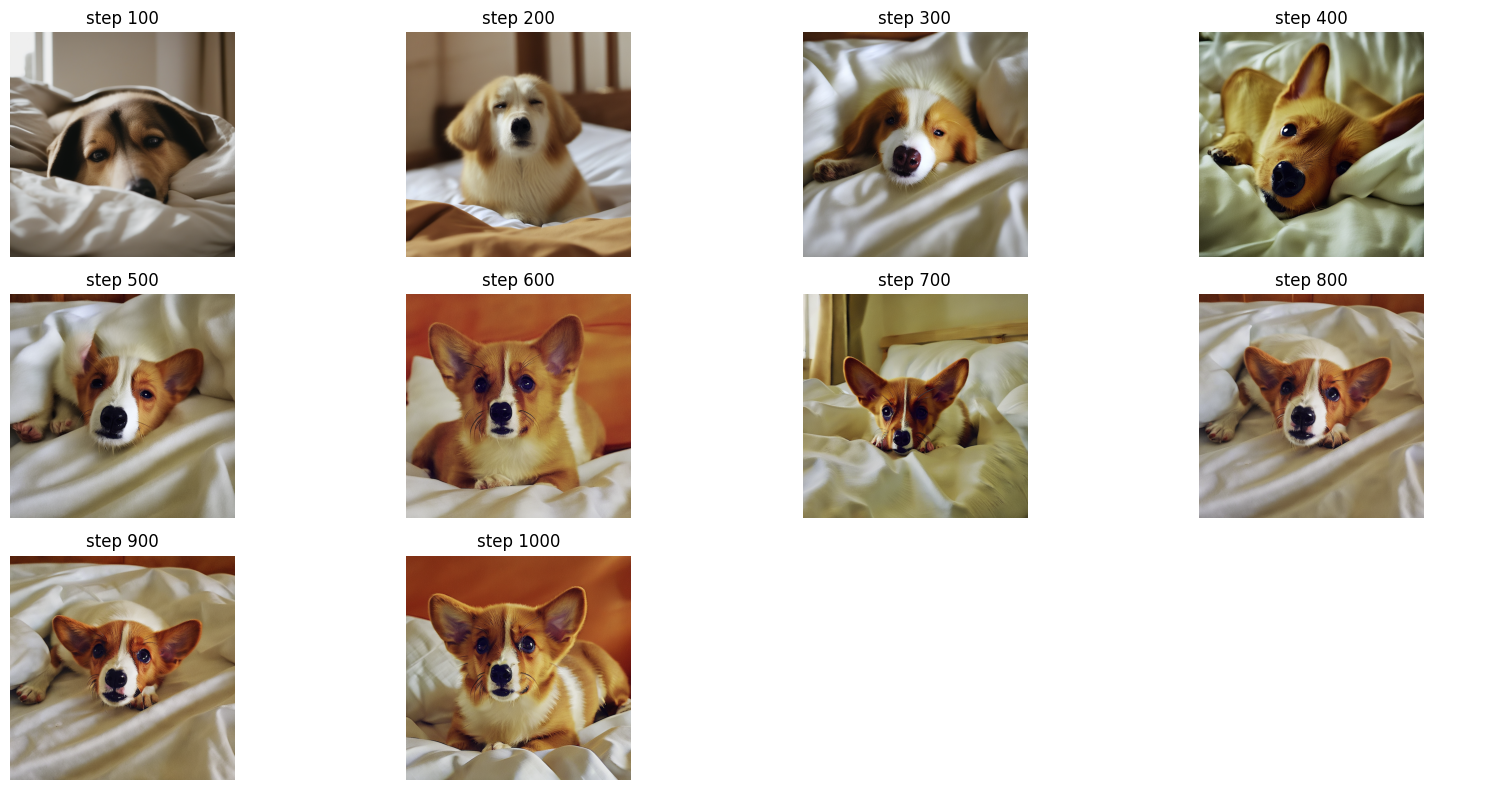

In [7]:
cols = 4 
rows = (len(images) + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(16, 8))
axs = axs.flatten()

for i, (img, title) in enumerate(zip(images, titles)):
    axs[i].set_title(title)
    axs[i].axis("off")
    if img:
        axs[i].imshow(img)

for j in range(len(images), len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
def load_images(image_paths):
    imgs = []
    for p in image_paths:
        if isinstance(p, Image.Image):
            imgs.append(p)
        else:
            imgs.append(Image.open(p).convert("RGB"))
    return imgs

def compute_editability_scores(steps, base_dir, prompt_dirs):
    edit_scores = {}

    # prompt_dirs = [
    #     d for d in sorted(os.listdir(base_dir)) 
    #     if os.path.isdir(os.path.join(base_dir, d)) and d != ".ipynb_checkpoints" and d != "A photo of sks dog"
    # ]
    # print(prompt_dirs)
    for step in steps:
        all_scores = []
        
        for prompt in prompt_dirs:
            folder = f"{base_dir}/checkpoint-{step}/samples/ns30_gs7.5/version_0/{prompt}/"

            if not os.path.exists(folder) or not os.listdir(folder):
                print(f"Step {step} | Prompt '{prompt}': изображения не найдены")
                continue

            gen_paths = [
                os.path.join(folder, f)
                for f in sorted(os.listdir(folder))
                if f.lower().endswith(("png", "jpg", "jpeg"))
            ]
            
            gen_paths = gen_paths[:5]
            generated_images = load_images(gen_paths)

            score = editability_score(generated_images, prompt)
            all_scores.append(score)
            # print(f"Step {step} | Prompt '{prompt}' | score: {score:.4f}")

        edit_scores[step] = sum(all_scores) / len(all_scores) if all_scores else None
        print(f"Step {step} | total editability score: {edit_scores[step]:.4f}")

    return edit_scores

In [9]:
steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
base_dir = "tlora_1000_steps/00001-aae1-dog_example_tortho_lora4"

edit_scores = compute_editability_scores(steps, base_dir, live_set + object_set)

Step 100 | total editability score: 0.3493
Step 200 | total editability score: 0.3476
Step 300 | total editability score: 0.3416
Step 400 | total editability score: 0.3380
Step 500 | total editability score: 0.3328
Step 600 | total editability score: 0.3292
Step 700 | total editability score: 0.3280
Step 800 | total editability score: 0.3270
Step 900 | total editability score: 0.3250
Step 1000 | total editability score: 0.3231


In [10]:
edit_scores

{100: 0.34933373235887094,
 200: 0.3476365612399194,
 300: 0.3415881741431452,
 400: 0.33803632182459675,
 500: 0.33280698714717744,
 600: 0.32923150831653225,
 700: 0.32802655619959675,
 800: 0.3269909274193548,
 900: 0.3249708606350806,
 1000: 0.3231319304435484}

In [20]:
edit_scores

{700: 0.32802655619959675,
 800: 0.3269909274193548,
 900: 0.3249708606350806,
 1000: 0.3231319304435484}

In [12]:
right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}

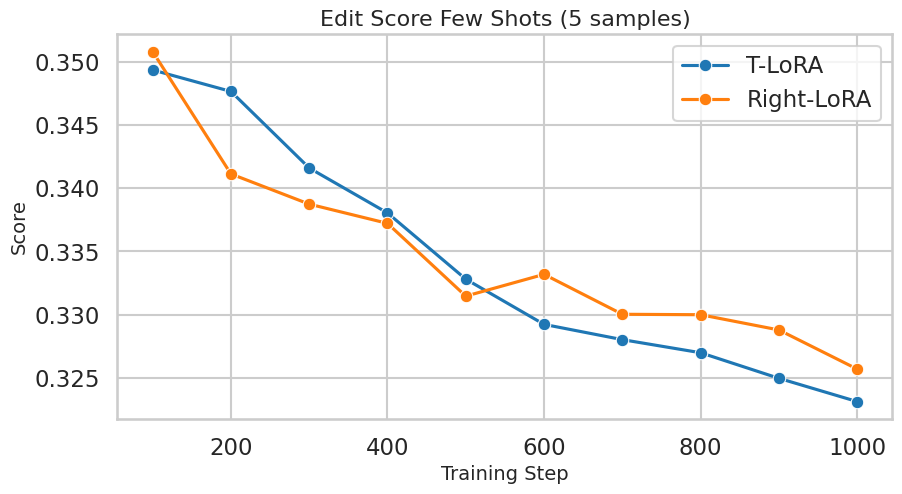

In [13]:
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
sns.set_context("talk")

df_tlora_edit = pd.DataFrame({
    "step": list(edit_scores.keys()),
    "score": list(edit_scores.values())
})
df_tlora_edit = df_tlora_edit.dropna()

df_right_dynamic_lora_edit = pd.DataFrame({
    "step": list(right_edit_few.keys()),
    "score": list(right_edit_few.values())
})
df_right_dynamic_lora_edit = df_right_dynamic_lora_edit.dropna()


plt.figure(figsize=(10, 5))
sns.lineplot(data=df_tlora_edit, x="step", y="score", marker="o", label="T-LoRA")
sns.lineplot(data=df_right_dynamic_lora_edit, x="step", y="score", marker="o", label="Right-LoRA")
plt.title("Edit Score Few Shots (5 samples)", fontsize=16)
plt.xlabel("Training Step", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.grid(True)
# plt.tight_layout()
plt.show()

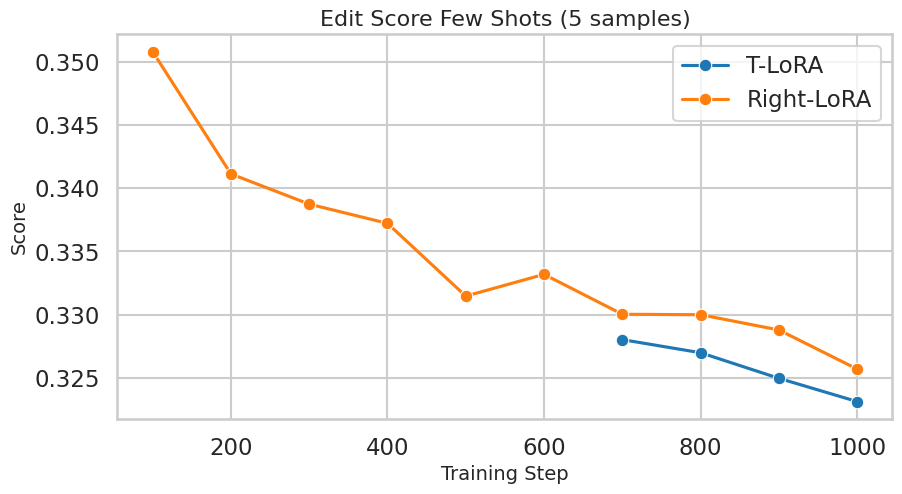

In [23]:
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
sns.set_context("talk")

df_tlora_edit = pd.DataFrame({
    "step": list(edit_scores.keys()),
    "score": list(edit_scores.values())
})
df_tlora_edit = df_tlora_edit.dropna()

df_right_dynamic_lora_edit = pd.DataFrame({
    "step": list(right_edit_few.keys()),
    "score": list(right_edit_few.values())
})
df_right_dynamic_lora_edit = df_right_dynamic_lora_edit.dropna()


plt.figure(figsize=(10, 5))
sns.lineplot(data=df_tlora_edit, x="step", y="score", marker="o", label="T-LoRA")
sns.lineplot(data=df_right_dynamic_lora_edit, x="step", y="score", marker="o", label="Right-LoRA")
plt.title("Edit Score Few Shots (5 samples)", fontsize=16)
plt.xlabel("Training Step", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.grid(True)
# plt.tight_layout()
plt.show()